In [25]:
# the libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.cm as cmaps
import pandas as pd
import seaborn as sns
import cartopy.crs as ccrs
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

In [26]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

In [27]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-15,25))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifc
#ocean_mask = masks.seamask ==1

In [28]:
fp = '/data/jmex/NOAA//latest/precip.mon.mean.nc'
tp = xr.open_dataset(fp).sel(lat = slice(-15,25), time = slice(None,None))
tp = tp.drop_vars(['time_bnds', 'lat_bnds', 'lon_bnds']).rename({'precip':'tp'})

fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15)).where(ocean_mask)


In [29]:
#interpolate to tp grid
sst = sst.interp(lat = tp.lat, lon = tp.lon, method = 'nearest')
#make new ocean mask to subselect tp field
ocean_mask2 = ~sst.isel(time = 1).sst.isnull()

#subselect tp field
tp = tp.where(ocean_mask2)

In [30]:
tp = tp.where(tp.time.dt.month.isin([8,9,10])).groupby('time.year').mean()


In [31]:
#tp = tp.weighted(np.cos(np.deg2rad(tp.lat))).mean(['lat', 'lon'])

In [32]:
# Assuming dt.tp and dt.year exist
dt = tp

composite_years = [1982, 1987, 1991, 1997, 2015, 2009]
dt_composite = dt.where(dt.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dt.tp, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dt.sel(year = 1982).tp, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dt.sel(year = 1987).tp, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 1991).tp, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dt.sel(year = 1997).tp, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 2009).tp, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 2015).tp, ymin=0, ymax=1, color='black', linewidth=1.5)


for y in dt_composite.year.values: 
    x = dt.sel(year = y).tp
    ax.annotate(y, (x, 0.75), rotation = 270)
        

x = dt.sel(year= 2023).tp
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.vlines(x, ymin=0, ymax = 0, color = 'k', linewidth = 1.5, label = 'Strong El-Niños')
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("TP [mm/day]", fontweight = 'normal')
#ax.set_title("Barcode Plot of dt.tp")

plt.legend(loc = 'upper left')
plt.show()


TypeError: only size-1 arrays can be converted to Python scalars

<Figure size 720x144 with 1 Axes>

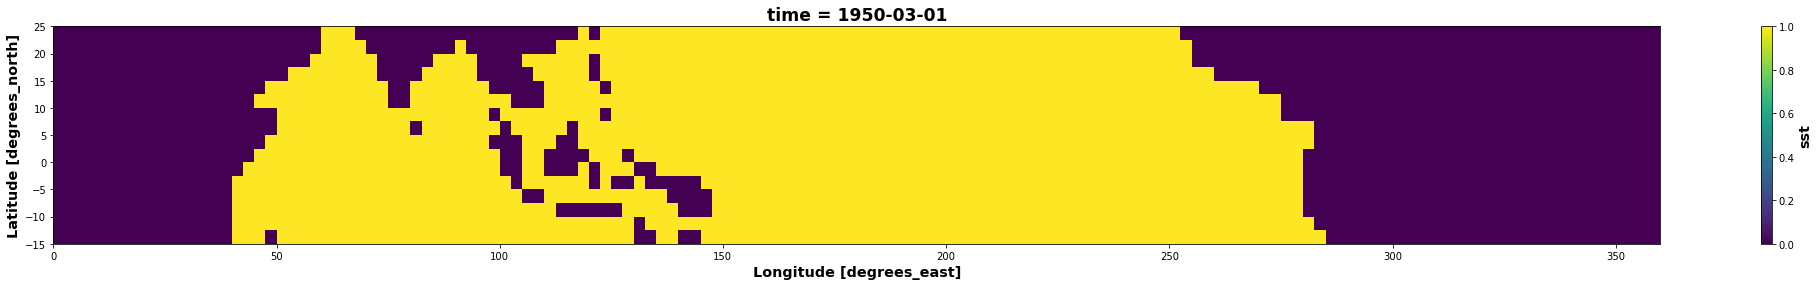

In [33]:
ocean_mask2.plot(size = 4, aspect = 9)

In [34]:
#tp = tp.where(tp.time.dt.month.isin([8,9,10])).groupby('time.year').mean()
tp = tp.weighted(np.cos(np.deg2rad(tp.lat))).mean('lat')

In [35]:
#compute anomaly
tp_clim = tp.sel(year = slice('1991', '2020')).mean('year')
tp = tp-tp_clim

In [36]:
#compute variablity
q10tp = tp.quantile(0.1, dim = 'year')
q90tp = tp.quantile(0.9, dim = 'year') 

/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1389: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


## Make composite event


In [ ]:
cyears =  [1982, 1987, 1991, 1997, 2009, 2015]

In [38]:
cmtp = tp.where(tp.year.isin(cyears), drop = True).mean('year')


In [39]:
cstdtp = tp.where(tp.year.isin(cyears), drop = True).std('year')

In [40]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15))
sst = sst.where(ocean_mask)

sst = sst.where(sst.time.dt.month.isin([8,9,10])).groupby('time.year').mean()
sst = sst.weighted(np.cos(np.deg2rad(sst.lat))).mean('lat')


In [17]:
#compute anomaly
sst_clim = sst.sel(year = slice('1991', '2020')).mean('year')
sst = sst-sst_clim

In [18]:
#compute variablity
q10 = sst.quantile(0.1, dim = 'year')
q90 = sst.quantile(0.9, dim = 'year') 

/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1389: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


## Make composite event


In [19]:
cyears =  [1982, 1987, 1991, 1997, 2009, 2015]

In [20]:
cm = sst.where(sst.year.isin(cyears), drop = True).mean('year')
cm_1 = sst.where(sst.year.isin([y-1 for y in cyears]), drop = True).mean('year')


In [21]:
cstd = sst.where(sst.year.isin(cyears), drop = True).std('year')

In [22]:
#compute variablity
cq10 = sst.where(sst.year.isin(cyears), drop = True).min(dim = 'year')
cq90 = sst.where(sst.year.isin(cyears), drop = True).max(dim = 'year') 

#compute variablity
cq10tp = tp.where(tp.year.isin(cyears), drop = True).min(dim = 'year')
cq90tp = tp.where(tp.year.isin(cyears), drop = True).max(dim = 'year') 

In [23]:
brbg = cmaps.get_cmap('BrBG')
rdbur = cmaps.get_cmap('RdBu_r')

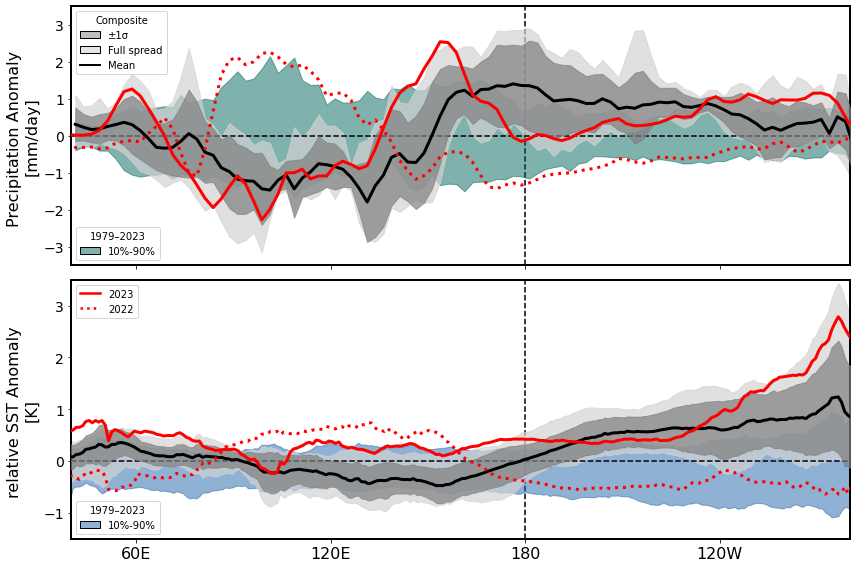

In [24]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(12, 8))


#------------------PRECIP NOW ON TOP-----------------------
ax = axs[0]  # Precip on the top

# plot variability (nino)
ax.fill_between(cstdtp.lon, (cmtp + cstdtp).tp, (cmtp - cstdtp).tp,
                color='grey', alpha=0.7, label='+/- σ', zorder=10)

# all variability
ax.fill_between(q10tp.lon, q10tp.tp, q90tp.tp,
                color=brbg(0.9), alpha=0.5, label='10%-90% of (1979-2024)')

ax.fill_between(cq10tp.lon, cq10tp.tp, cq90tp.tp,
                color = 'lightgrey', alpha = 0.7, label = 'Full Spread Composite')


"""cq10tp.tp.plot(ax = ax, linestyle = 'dotted', c = 'k')
cq90tp.tp.plot(ax = ax, linestyle = 'dotted', c = 'k')
"""

tp.sel(year=2023).rolling(lon = 3, center=True, min_periods = 1).mean().tp.plot(ax=ax, c='r', linewidth=3, label='2023', zorder=15)
tp.sel(year=2022).rolling(lon = 3, center=True, min_periods = 1).mean().tp.plot(ax=ax, c='red', linestyle='dotted', linewidth=3, label='2022', zorder=14)
cmtp.tp.plot(c='k', label='Composite', zorder=12, ax=ax, linewidth = 3)
#cmtp_1.tp.plot(c='k', label='Composite [-1]', zorder=12, ax=ax, linestyle='--')


ax.set_ylim(-3.5, 3.5)
ax.axhline(0, c='k', linestyle='--')
ax.set_ylabel('Precipitation Anomaly \n[mm/day]', fontweight='normal', fontsize=16)

#------------------SST NOW ON BOTTOM-----------------------
ax = axs[1]  # SST on the bottom

# plot variability (nino)
ax.fill_between(cstd.lon, (cm + cstd).sst, (cm - cstd).sst,
                color='grey', alpha=0.7, label='+/- σ', zorder=10)

# all variability
ax.fill_between(q10.lon, q10.sst, q90.sst,
                color=rdbur(0.1), alpha=0.5, label='10%-90% of (1979-2024)')
#all variability
ax.fill_between(cq10.lon, cq10.sst, cq90.sst,
                color = 'lightgrey', alpha = 0.7, label = 'Full Spread Composite')

"""cq10.sst.plot(ax = ax, linestyle = 'dotted', c = 'k')
cq90.sst.plot(ax = ax, linestyle = 'dotted', c = 'k', label = 'Full Spread Composite')
"""

sst.sel(year=2023).sst.plot(ax=ax, c='r', linewidth=3, label='2023', zorder=15)
sst.sel(year=2022).sst.plot(ax=ax, c='red', linestyle='dotted', linewidth=3, label='2022', zorder=14)
cm.sst.plot(c='k', label='Composite', linewidth = 3, zorder=12, ax=ax)
#cm_1.sst.plot(c='k', label='Composite [-1]', zorder=12, ax=ax, linestyle='--')


ax.set_ylim(-1.5, 3.5)
ax.axhline(0, c='k', linestyle='--')
ax.set_xlabel('')
#ax.set_xlabel('Longitude [deg]', fontweight='normal', fontsize=16)
ax.set_ylabel('relative SST Anomaly \n[K]', fontweight='normal', fontsize=16)
ax.legend(loc='upper left', fontsize=14)


# Vertical reference line at 180° and shared settings
for ax in axs:
    ax.axvline(180, linestyle='--', c='k', zorder=0)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_title('')
    ax.spines[:].set_linewidth(2)

axs[0].set_xlim(40, 280)  # shared x-axis

axs[0].set_xlabel('')

# Set x-axis ticks and labels
xticks = [60, 120, 180, 240, ]
xlabels = ['60E', '120E', '180', '120W']
axs[1].set_xticks(xticks)
axs[1].set_xticklabels(xlabels, fontsize=16)




###################################
# Colormaps and custom colors
brbg = cmaps.get_cmap('BrBG')
rdbu = cmaps.get_cmap('RdBu_r')

brbg_trans = (*brbg(0.9)[:3], 0.5)
rdbu_trans = (*rdbu(0.1)[:3], 0.5)

# Custom fixed colors
grey = (0.5, 0.5, 0.5, 0.5)
lightgrey = (0.8, 0.8, 0.8, 0.5)


# --- ax[0] ---

# Composite legend (left): add_artist
legend_0_composite = [
    Patch(facecolor=grey, edgecolor='black', label='±1σ'),
    Patch(facecolor=lightgrey, edgecolor='black', label='Full spread'),
    Line2D([0], [0], color='black', linewidth=2.0, label='Mean')
]
composite_legend_0 = axs[0].legend(
    handles=legend_0_composite, title='Composite', loc='upper left'
)
axs[0].add_artist(composite_legend_0)

# Main legend (right): set as standard
legend_0_main = [
    Patch(facecolor=brbg_trans, edgecolor='black', label='10%-90%')
]
axs[0].legend(handles=legend_0_main, title='1979–2023', loc='lower left')


# --- ax[1] ---

# Year lines legend (left): add_artist
legend_1_years = [
    Line2D([0], [0], color='red', linewidth=2.5, label='2023'),
    Line2D([0], [0], color='red', linewidth=2.5, label='2022', linestyle = 'dotted')
]
years_legend_1 = axs[1].legend(handles=legend_1_years, loc='upper left')
axs[1].add_artist(years_legend_1)

# Main legend (right): set as standard
legend_1_main = [
    Patch(facecolor=rdbu_trans, edgecolor='black', label='10%-90%')
]
axs[1].legend(handles=legend_1_main, title='1979–2023', loc='lower left')



plt.tight_layout()
fig.savefig('Figures/Fig3g.png', dpi = 600, format = 'png')

